In [4]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz
from xgboost import XGBClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [5]:
# Загрузка данных (в данном случае используем набор данных Iris)
data = load_iris()
X = data.data
y = data.target

In [6]:
# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Создание и обучение дерева решений
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [8]:
# Прогнозирование и оценка точности дерева решений
dt_predictions = dt_classifier.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)
print(f"Accuracy of Decision Tree: {dt_accuracy:.2f}")

Accuracy of Decision Tree: 1.00


In [9]:
# Визуализация дерева решений
dot_data = export_graphviz(dt_classifier, out_file=None,
                           feature_names=data.feature_names,
                           class_names=data.target_names,
                           filled=True, rounded=True,
                           special_characters=True)
graph = graphviz.Source(dot_data)
graph.render("decision_tree")  # Сохранит дерево в файл decision_tree.pdf
graph.view()  # Откроет визуализацию дерева

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [10]:
# Создание и обучение модели XGBoost
xgb_classifier = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_classifier.fit(X_train, y_train)

c:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:20:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [11]:
# Прогнозирование и оценка точности модели XGBoost
xgb_predictions = xgb_classifier.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print(f"Accuracy of XGBoost: {xgb_accuracy:.2f}")

Accuracy of XGBoost: 1.00


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

<Figure size 2000x1000 with 0 Axes>

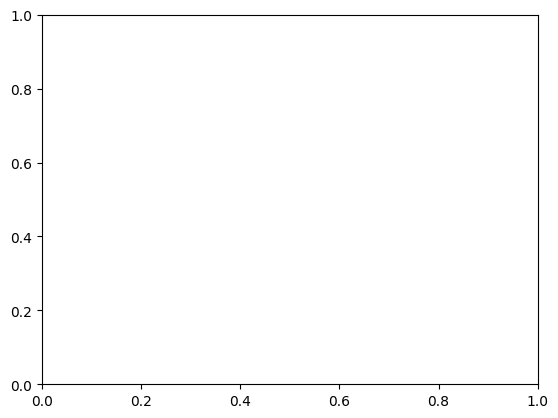

In [12]:
# Визуализация дерева XGBoost без дополнительных параметров
plt.figure(figsize=(20, 10))
plot_tree(xgb_classifier, num_trees=0)  # Убираем fmap и другие параметры
plt.title("XGBoost Tree")
plt.savefig("xgboost_tree.png")  # Сохранит дерево в файл xgboost_tree.png
plt.show()  # Отобразит дерево